In [ ]:
!pip install lime

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import gdown
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.combine import SMOTETomek
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from itertools import cycle
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import shap
import lime
import lime.lime_tabular
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# Download dataset
file_id = '1lrpkRl2Ef7Ly5MoWgJxEKAEUWeH3ZNyv'
url = f'https://drive.google.com/uc?id={file_id}'
gdown.download(url, quiet=False)

# Load and preprocess data
df = pd.read_csv("Predict Students’ Dropout and Academic Success.csv")

# Encode target variable
target_column = "Target"
le = LabelEncoder()
df[target_column] = le.fit_transform(df[target_column])
class_names = le.classes_

# Split features and target
X = df.drop(columns=[target_column])
y = df[target_column]
original_features = X.columns.tolist()

# One-hot encoding
X = pd.get_dummies(X)
X_columns = X.columns.tolist()

# Balance dataset using SMOTETomek
smote = SMOTETomek(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bal)

Downloading...
From: https://drive.google.com/uc?id=1lrpkRl2Ef7Ly5MoWgJxEKAEUWeH3ZNyv
To: /content/Predict Students’ Dropout and Academic Success.csv
100%|██████████| 529k/529k [00:00<00:00, 59.7MB/s]



Distribusi Label Sebelum SMOTETomek:
Dropout: 1421
Enrolled: 794
Graduate: 2209


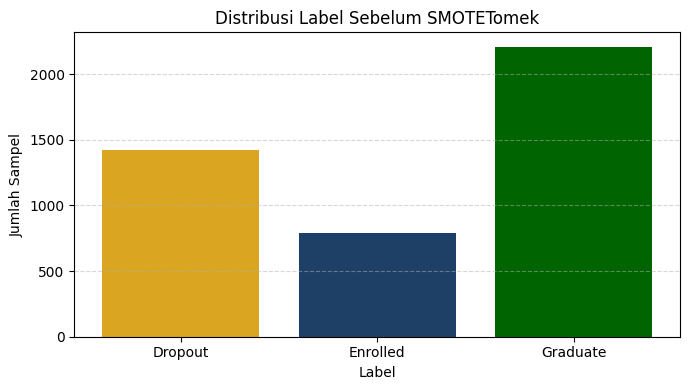


Distribusi Label Setelah SMOTETomek:
Dropout: 2111
Enrolled: 2153
Graduate: 2089


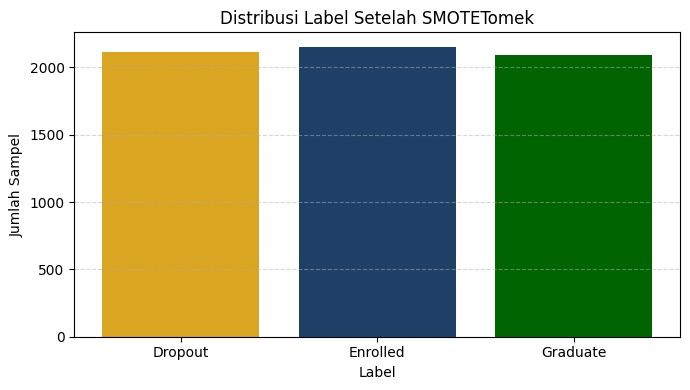

In [ ]:
# --- 4. Visualisasi Sebelum Balancing ---
label_map = {i: label for i, label in enumerate(le.classes_)}
desired_order = ['Dropout', 'Enrolled', 'Graduate']
ordered_labels = [list(le.classes_).index(lbl) for lbl in desired_order]
dark_colors = ['#DAA520', '#1E3F66', '#006400']  # kuning tua, biru tua, hijau tua

# Calculate and print the class distribution before SMOTETomek
label_counts_before = y.value_counts().sort_index().reindex(ordered_labels)

print("\nDistribusi Label Sebelum SMOTETomek:")
for i in ordered_labels:
    print(f"{label_map[i]}: {label_counts_before[i]}")

# Plot class distribution before SMOTETomek
plt.figure(figsize=(7, 4))
plt.bar([label_map[i] for i in ordered_labels],
        [label_counts_before[i] for i in ordered_labels],
        color=dark_colors)
plt.title("Distribusi Label Sebelum SMOTETomek")
plt.xlabel("Label")
plt.ylabel("Jumlah Sampel")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- 5. Visualisasi Setelah Balancing ---
# Calculate and print the class distribution after SMOTETomek
label_counts_after = pd.Series(y_bal).value_counts().sort_index().reindex(ordered_labels)

print("\nDistribusi Label Setelah SMOTETomek:")
for i in ordered_labels:
    print(f"{label_map[i]}: {label_counts_after[i]}")

# Plot class distribution after SMOTETomek
plt.figure(figsize=(7, 4))
plt.bar([label_map[i] for i in ordered_labels],
        [label_counts_after[i] for i in ordered_labels],
        color=dark_colors)
plt.title("Distribusi Label Setelah SMOTETomek")
plt.xlabel("Label")
plt.ylabel("Jumlah Sampel")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
class ProjectionHead(nn.Module):
    def __init__(self, input_dim, output_dim=512):
        super().__init__()
        self.fc = nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return F.normalize(self.fc(x), dim=1)

class ContrastiveModel(nn.Module):
    def __init__(self, input_dim, embed_dim=512):
        super().__init__()
        self.encoder = nn.Linear(input_dim, embed_dim)
        self.projector = ProjectionHead(embed_dim, embed_dim)
    def forward(self, x):
        return self.projector(F.relu(self.encoder(x)))

# Supervised contrastive loss
def supervised_contrastive_loss(features, labels, temperature=0.1):
    device = features.device
    labels = labels.contiguous().view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(device)
    anchor_dot_contrast = torch.div(torch.matmul(features, features.T), temperature)
    logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
    logits = anchor_dot_contrast - logits_max.detach()
    exp_logits = torch.exp(logits) * (1 - torch.eye(features.shape[0]).to(device))
    log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-10)
    mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-10)
    return -mean_log_prob_pos.mean()

In [ ]:
# Train SCL model
print("Training SCL...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_scaled.shape[1]

scl_model = ContrastiveModel(input_dim, embed_dim=512).to(device)
optimizer = torch.optim.Adam(scl_model.parameters(), lr=0.001)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_bal.values, dtype=torch.long)
dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

scl_model.train()
for epoch in range(150):
    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        features = scl_model(batch_x)
        loss = supervised_contrastive_loss(features, batch_y, temperature=1.0)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# Generate embeddings
scl_model.eval()
with torch.no_grad():
    embeddings = scl_model(X_tensor.to(device)).cpu().numpy()

print("SCL training completed and embeddings generated.")

Training SCL...
SCL training completed and embeddings generated.


In [ ]:
# Split data for classification (raw data and embeddings)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_scaled, y_bal, test_size=0.2, random_state=42)
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(embeddings, y_bal, test_size=0.2, random_state=42)

In [ ]:
# Initialize Random Forest classifiers for raw data and embeddings
rf_clf_raw = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf_emb = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
# Train and evaluate on raw data
print("\nEvaluating on Raw Data...")
rf_clf_raw.fit(X_train_raw, y_train_raw)
y_pred_raw = rf_clf_raw.predict(X_test_raw)
y_pred_proba_raw = rf_clf_raw.predict_proba(X_test_raw)

# Calculate metrics for raw data
accuracy_raw = accuracy_score(y_test_raw, y_pred_raw)
f1_raw = f1_score(y_test_raw, y_pred_raw, average='weighted')
roc_auc_raw = roc_auc_score(y_test_raw, y_pred_proba_raw, multi_class='ovr')

# Print classification report for raw data
print("\nClassification Report (Raw Data):")
print(classification_report(y_test_raw, y_pred_raw, target_names=class_names))

# Print metrics for raw data
print(f"\nRaw Data Metrics:")
print(f"Accuracy: {accuracy_raw:.4f}")
print(f"F1-Score (Weighted): {f1_raw:.4f}")
print(f"AUC-ROC (OvR): {roc_auc_raw:.4f}")


Evaluating on Raw Data...

Classification Report (Raw Data):
              precision    recall  f1-score   support

     Dropout       0.92      0.83      0.87       432
    Enrolled       0.80      0.82      0.81       428
    Graduate       0.82      0.87      0.84       411

    accuracy                           0.84      1271
   macro avg       0.84      0.84      0.84      1271
weighted avg       0.85      0.84      0.84      1271


Raw Data Metrics:
Accuracy: 0.8419
F1-Score (Weighted): 0.8425
AUC-ROC (OvR): 0.9552


In [ ]:
# Train and evaluate on embedding data
print("\nEvaluating on Embedding Data...")
rf_clf_emb.fit(X_train_emb, y_train_emb)
y_pred_emb = rf_clf_emb.predict(X_test_emb)
y_pred_proba_emb = rf_clf_emb.predict_proba(X_test_emb)

# Calculate metrics for embedding data
accuracy_emb = accuracy_score(y_test_emb, y_pred_emb)
f1_emb = f1_score(y_test_emb, y_pred_emb, average='weighted')
roc_auc_emb = roc_auc_score(y_test_emb, y_pred_proba_emb, multi_class='ovr')

# Print classification report for embedding data
print("\nClassification Report (Embedding Data):")
print(classification_report(y_test_emb, y_pred_emb, target_names=class_names))

# Print metrics for embedding data
print(f"\nEmbedding Data Metrics:")
print(f"Accuracy: {accuracy_emb:.4f}")
print(f"F1-Score (Weighted): {f1_emb:.4f}")
print(f"AUC-ROC (OvR): {roc_auc_emb:.4f}")


Evaluating on Embedding Data...

Classification Report (Embedding Data):
              precision    recall  f1-score   support

     Dropout       0.99      1.00      0.99       432
    Enrolled       0.98      0.99      0.99       428
    Graduate       0.99      0.98      0.99       411

    accuracy                           0.99      1271
   macro avg       0.99      0.99      0.99      1271
weighted avg       0.99      0.99      0.99      1271


Embedding Data Metrics:
Accuracy: 0.9874
F1-Score (Weighted): 0.9874
AUC-ROC (OvR): 0.9985



Computing SHAP Local Feature Importance for Instance...
Debug Info for Raw Data:
X_test_raw shape: (1271, 36)
Type of shap_values_raw: <class 'numpy.ndarray'>
Length of shap_values_raw (n_classes): 1271
shap_values_raw[0] shape: (36, 3)
shap_values_raw[1] shape: (36, 3)
shap_values_raw[2] shape: (36, 3)
shap_values_raw[3] shape: (36, 3)
shap_values_raw[4] shape: (36, 3)
shap_values_raw[5] shape: (36, 3)
shap_values_raw[6] shape: (36, 3)
shap_values_raw[7] shape: (36, 3)
shap_values_raw[8] shape: (36, 3)
shap_values_raw[9] shape: (36, 3)
shap_values_raw[10] shape: (36, 3)
shap_values_raw[11] shape: (36, 3)
shap_values_raw[12] shape: (36, 3)
shap_values_raw[13] shape: (36, 3)
shap_values_raw[14] shape: (36, 3)
shap_values_raw[15] shape: (36, 3)
shap_values_raw[16] shape: (36, 3)
shap_values_raw[17] shape: (36, 3)
shap_values_raw[18] shape: (36, 3)
shap_values_raw[19] shape: (36, 3)
shap_values_raw[20] shape: (36, 3)
shap_values_raw[21] shape: (36, 3)
shap_values_raw[22] shape: (36, 3)
s

<Figure size 1000x600 with 0 Axes>

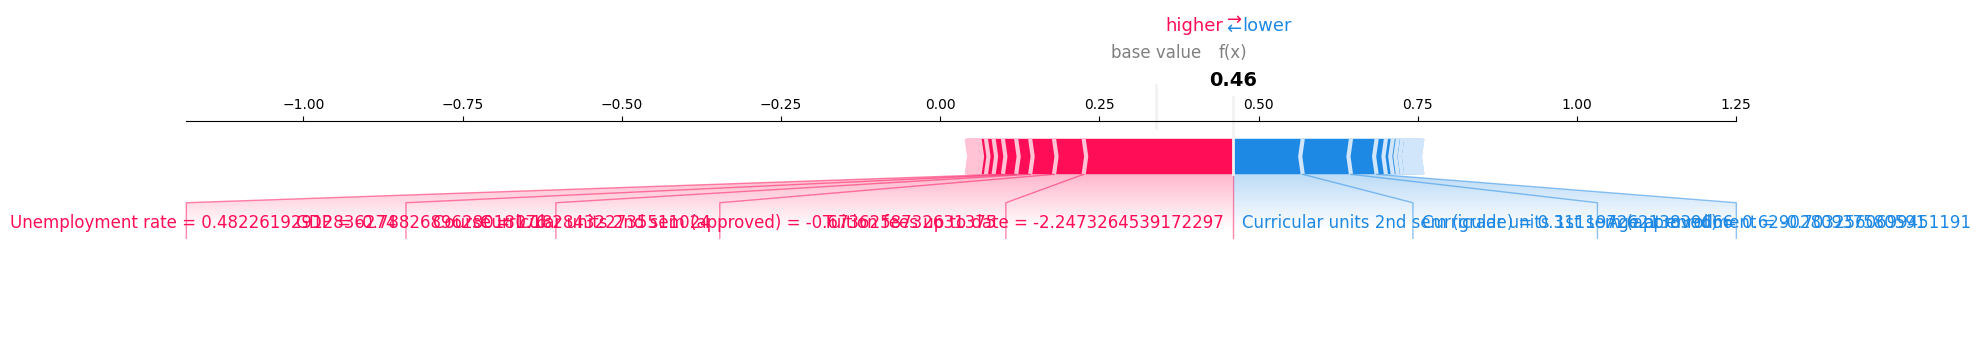

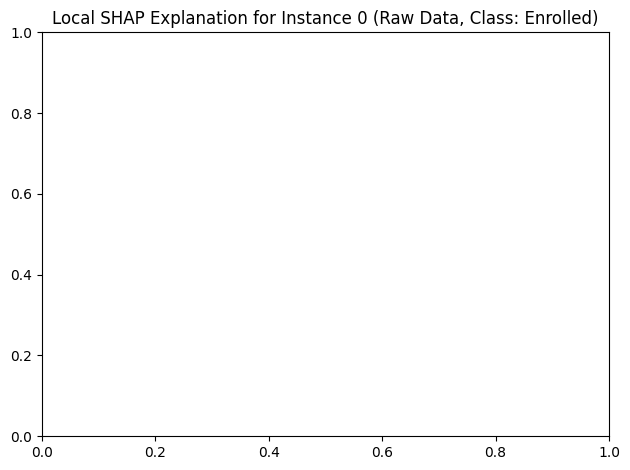

<Figure size 1000x600 with 0 Axes>

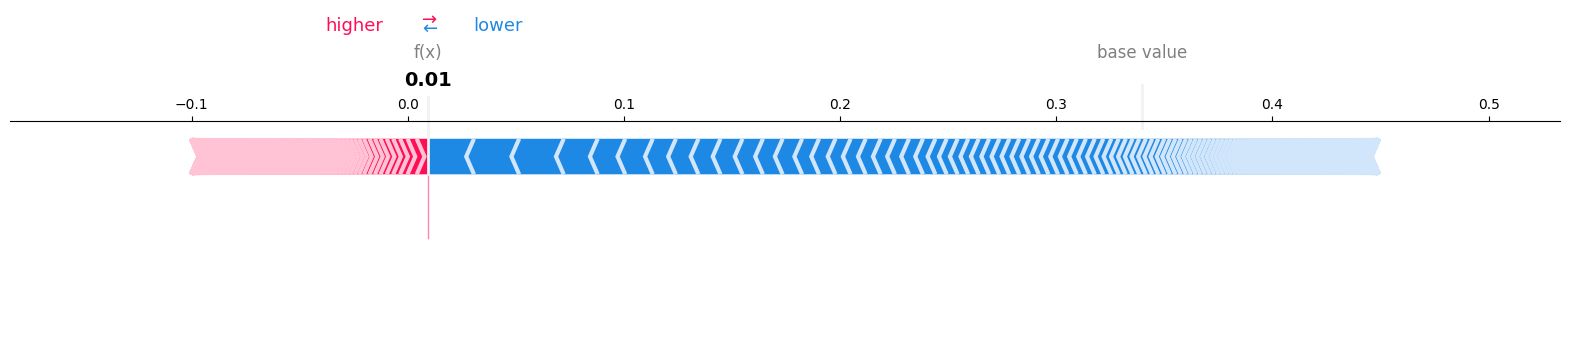

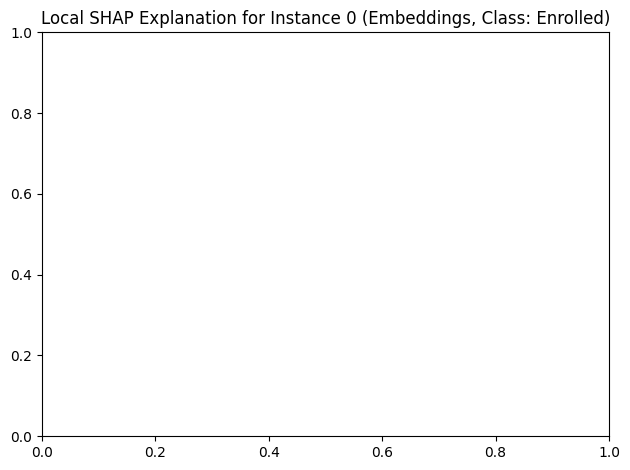

In [ ]:
# --- SHAP Analysis for Local Instance ---
print("\nComputing SHAP Local Feature Importance for Instance...")

# SHAP for Raw Data
explainer_raw = shap.TreeExplainer(rf_clf_raw)
shap_values_raw = explainer_raw.shap_values(X_test_raw)

# SHAP for Embeddings
explainer_emb = shap.TreeExplainer(rf_clf_emb)
shap_values_emb = explainer_emb.shap_values(X_test_emb)

# Local SHAP explanation for a single instance (e.g., instance_idx = 0)
instance_idx = 0

# Debug: Inspect SHAP values structure
print("Debug Info for Raw Data:")
print(f"X_test_raw shape: {X_test_raw.shape}")
print(f"Type of shap_values_raw: {type(shap_values_raw)}")
print(f"Length of shap_values_raw (n_classes): {len(shap_values_raw)}")
for i, class_shap in enumerate(shap_values_raw):
    print(f"shap_values_raw[{i}] shape: {class_shap.shape}")
print(f"X_test_raw[{instance_idx}] shape: {X_test_raw[instance_idx].shape}")
print(f"shap_values_raw[1][{instance_idx}] shape: {shap_values_raw[1][instance_idx].shape}")
print(f"Number of feature names (X_columns): {len(X_columns)}")

print("\nDebug Info for Embeddings:")
print(f"X_test_emb shape: {X_test_emb.shape}")
print(f"Type of shap_values_emb: {type(shap_values_emb)}")
print(f"Length of shap_values_emb (n_classes): {len(shap_values_emb)}")
for i, class_shap in enumerate(shap_values_emb):
    print(f"shap_values_emb[{i}] shape: {class_shap.shape}")
print(f"X_test_emb[{instance_idx}] shape: {X_test_emb[instance_idx].shape}")
print(f"shap_values_emb[1][{instance_idx}] shape: {shap_values_emb[1][instance_idx].shape}")
print(f"Number of embedding feature names: {len([f'Embedding_{i}' for i in range(X_test_emb.shape[1])])}")

# Verify dimension consistency
if shap_values_raw[1][instance_idx].shape[0] != X_test_raw[instance_idx].shape[0]:
    print("Warning: Dimension mismatch detected for raw data. Attempting to fix SHAP values...")
    # Check if shap_values_raw[1] is transposed
    if shap_values_raw[1].shape == (X_test_raw.shape[1], len(class_names)):
        print("SHAP values appear transposed. Transposing back...")
        shap_values_raw = [np.transpose(shap_values_raw[i], (1, 0)) for i in range(len(shap_values_raw))]
        print(f"New shap_values_raw[1] shape: {shap_values_raw[1].shape}")

if shap_values_emb[1][instance_idx].shape[0] != X_test_emb[instance_idx].shape[0]:
    print("Warning: Dimension mismatch detected for embeddings. Attempting to fix SHAP values...")
    if shap_values_emb[1].shape == (X_test_emb.shape[1], len(class_names)):
        print("SHAP values appear transposed. Transposing back...")
        shap_values_emb = [np.transpose(shap_values_emb[i], (1, 0)) for i in range(len(shap_values_emb))]
        print(f"New shap_values_emb[1] shape: {shap_values_emb[1].shape}")

# Re-verify dimension consistency after potential fix
if X_test_raw[instance_idx].shape[0] != shap_values_raw[1][instance_idx].shape[0]:
    raise ValueError(f"Dimension mismatch for raw data: features ({X_test_raw[instance_idx].shape[0]}) != SHAP values ({shap_values_raw[1][instance_idx].shape[0]})")
if len(X_columns) != X_test_raw[instance_idx].shape[0]:
    raise ValueError(f"Feature names length ({len(X_columns)}) != feature values length ({X_test_raw[instance_idx].shape[0]})")

if X_test_emb[instance_idx].shape[0] != shap_values_emb[1][instance_idx].shape[0]:
    raise ValueError(f"Dimension mismatch for embeddings: features ({X_test_emb[instance_idx].shape[0]}) != SHAP values ({shap_values_emb[1][instance_idx].shape[0]})")
if len([f'Embedding_{i}' for i in range(X_test_emb.shape[1])]) != X_test_emb[instance_idx].shape[0]:
    raise ValueError(f"Embedding feature names length ({len([f'Embedding_{i}' for i in range(X_test_emb.shape[1])])}) != feature values length ({X_test_emb[instance_idx].shape[0]})")

# For raw data
plt.figure(figsize=(10, 6))
shap.force_plot(
    explainer_raw.expected_value[1],  # Base value for class 1
    shap_values_raw[1][instance_idx],  # SHAP values for class 1, instance 0
    X_test_raw[instance_idx],  # Feature values for instance 0
    feature_names=X_columns,  # Feature names
    matplotlib=True  # Static plot for Colab
)
plt.title(f"Local SHAP Explanation for Instance {instance_idx} (Raw Data, Class: {class_names[1]})")
plt.tight_layout()
plt.show()

# For embeddings
plt.figure(figsize=(10, 6))
shap.force_plot(
    explainer_emb.expected_value[1],  # Base value for class 1
    shap_values_emb[1][instance_idx],  # SHAP values for class 1, instance 0
    X_test_emb[instance_idx],  # Feature values for instance 0
    feature_names=[f'Embedding_{i}' for i in range(X_test_emb.shape[1])],  # Embedding feature names
    matplotlib=True  # Static plot for Colab
)
plt.title(f"Local SHAP Explanation for Instance {instance_idx} (Embeddings, Class: {class_names[1]})")
plt.tight_layout()
plt.show()


Computing LIME Local Feature Importance for Instance...


<Figure size 1000x600 with 0 Axes>

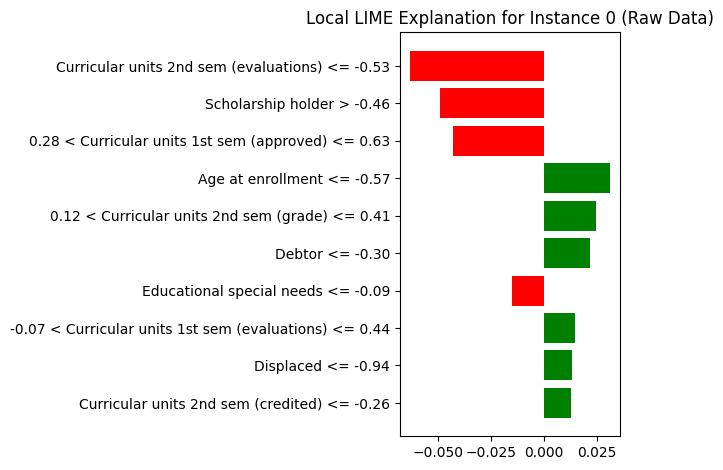

<Figure size 1000x600 with 0 Axes>

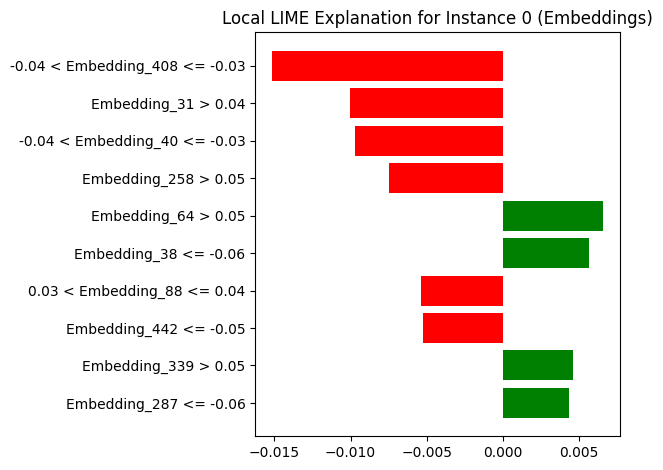


Local SHAP and LIME analysis for instance completed.


In [ ]:
# --- LIME Analysis for Local Instance ---
print("\nComputing LIME Local Feature Importance for Instance...")

# LIME for Raw Data
lime_explainer_raw = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_raw,
    feature_names=X_columns,
    class_names=class_names,
    mode='classification'
)

# LIME for Embeddings
lime_explainer_emb = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_emb,
    feature_names=[f'Embedding_{i}' for i in range(X_train_emb.shape[1])],
    class_names=class_names,
    mode='classification'
)

# Local LIME explanation for the same instance (instance_idx = 0)
# For raw data
exp_raw = lime_explainer_raw.explain_instance(
    X_test_raw[instance_idx],
    rf_clf_raw.predict_proba,
    num_features=10
)
plt.figure(figsize=(10, 6))
exp_raw.as_pyplot_figure()
plt.title(f"Local LIME Explanation for Instance {instance_idx} (Raw Data)")
plt.tight_layout()
plt.show()

# For embeddings
exp_emb = lime_explainer_emb.explain_instance(
    X_test_emb[instance_idx],
    rf_clf_emb.predict_proba,
    num_features=10
)
plt.figure(figsize=(10, 6))
exp_emb.as_pyplot_figure()
plt.title(f"Local LIME Explanation for Instance {instance_idx} (Embeddings)")
plt.tight_layout()
plt.show()

print("\nLocal SHAP and LIME analysis for instance completed.")


Aggregating and Sorting Combined SHAP and LIME Feature Importance for Instance...


/tmp/ipython-input-3090423157.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Combined_Importance', y='Feature', data=combined_importance_raw.head(10), palette='viridis')


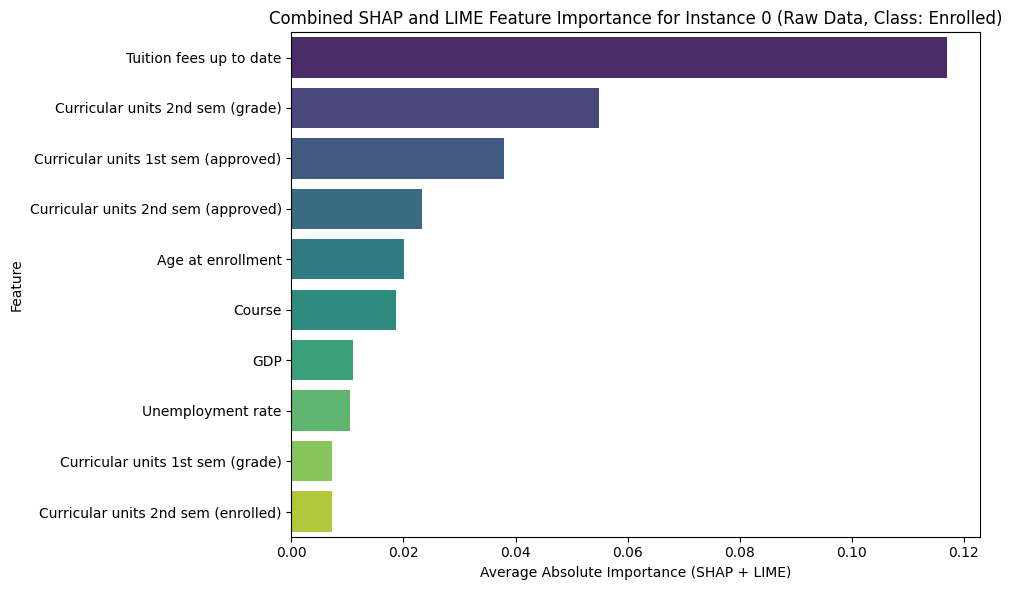

/tmp/ipython-input-3090423157.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Combined_Importance', y='Feature', data=combined_importance_emb.head(10), palette='viridis')


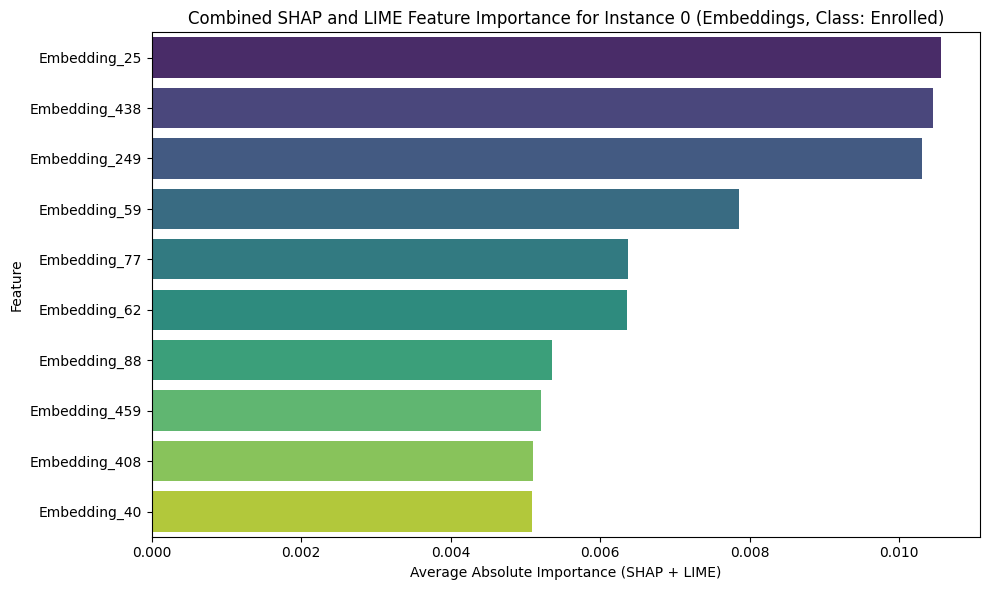


Top 10 Combined Feature Importance for Raw Data:
                            Feature  Combined_Importance
            Tuition fees up to date             0.117052
   Curricular units 2nd sem (grade)             0.054959
Curricular units 1st sem (approved)             0.037873
Curricular units 2nd sem (approved)             0.023294
                  Age at enrollment             0.020131
                             Course             0.018744
                                GDP             0.010978
                  Unemployment rate             0.010409
   Curricular units 1st sem (grade)             0.007327
Curricular units 2nd sem (enrolled)             0.007296

Top 10 Combined Feature Importance for Embeddings:
      Feature  Combined_Importance
 Embedding_25             0.010556
Embedding_438             0.010453
Embedding_249             0.010307
 Embedding_59             0.007858
 Embedding_77             0.006375
 Embedding_62             0.006365
 Embedding_88             

In [ ]:
# --- Aggregation and Sorting of Combined SHAP and LIME Feature Importance ---
print("\nAggregating and Sorting Combined SHAP and LIME Feature Importance for Instance...")

# Local instance index
instance_idx = 0

# Fix SHAP values if transposed
if shap_values_raw[1].shape == (X_test_raw.shape[1], len(class_names)):
    print("Warning: SHAP values for raw data appear transposed. Transposing back...")
    shap_values_raw = [np.transpose(shap_values_raw[i], (1, 0)) for i in range(len(shap_values_raw))]
    print(f"New shap_values_raw[1] shape: {shap_values_raw[1].shape}")

if shap_values_emb[1].shape == (X_test_emb.shape[1], len(class_names)):
    print("Warning: SHAP values for embeddings appear transposed. Transposing back...")
    shap_values_emb = [np.transpose(shap_values_emb[i], (1, 0)) for i in range(len(shap_values_emb))]
    print(f"New shap_values_emb[1] shape: {shap_values_emb[1].shape}")

# Verify dimension consistency
if X_test_raw[instance_idx].shape[0] != shap_values_raw[1][instance_idx].shape[0]:
    raise ValueError(f"Dimension mismatch for raw data: features ({X_test_raw[instance_idx].shape[0]}) != SHAP values ({shap_values_raw[1][instance_idx].shape[0]})")
if len(X_columns) != X_test_raw[instance_idx].shape[0]:
    raise ValueError(f"Feature names length ({len(X_columns)}) != feature values length ({X_test_raw[instance_idx].shape[0]})")

if X_test_emb[instance_idx].shape[0] != shap_values_emb[1][instance_idx].shape[0]:
    raise ValueError(f"Dimension mismatch for embeddings: features ({X_test_emb[instance_idx].shape[0]}) != SHAP values ({shap_values_emb[1][instance_idx].shape[0]})")
if len([f'Embedding_{i}' for i in range(X_test_emb.shape[1])]) != X_test_emb[instance_idx].shape[0]:
    raise ValueError(f"Embedding feature names length ({len([f'Embedding_{i}' for i in range(X_test_emb.shape[1])])}) != feature values length ({X_test_emb[instance_idx].shape[0]})")

# --- Compute LIME Explanations ---
# LIME for Raw Data
lime_explainer_raw = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_raw,
    feature_names=X_columns,
    class_names=class_names,
    mode='classification'
)

# LIME for Embeddings
embedding_feature_names = [f'Embedding_{i}' for i in range(X_test_emb.shape[1])]
lime_explainer_emb = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_emb,
    feature_names=embedding_feature_names,
    class_names=class_names,
    mode='classification'
)

# Compute LIME explanations for the instance
exp_raw = lime_explainer_raw.explain_instance(
    X_test_raw[instance_idx],
    rf_clf_raw.predict_proba,
    num_features=10
)
exp_emb = lime_explainer_emb.explain_instance(
    X_test_emb[instance_idx],
    rf_clf_emb.predict_proba,
    num_features=10
)

# --- Aggregate SHAP and LIME Importance ---
# For raw data
# SHAP importance
shap_importance_raw = pd.DataFrame({
    'Feature': X_columns,
    'SHAP_Importance': np.abs(shap_values_raw[1][instance_idx])  # Absolute SHAP values for class 1
})

# LIME importance (initialize with zeros for all features)
lime_importance_raw_dict = {feat: 0.0 for feat in X_columns}
for feat, weight in exp_raw.as_list():
    lime_importance_raw_dict[feat] = abs(weight)  # Absolute LIME weights
lime_importance_raw = pd.DataFrame({
    'Feature': X_columns,
    'LIME_Importance': [lime_importance_raw_dict[feat] for feat in X_columns]
})

# Combine SHAP and LIME
combined_importance_raw = shap_importance_raw.merge(lime_importance_raw, on='Feature')
combined_importance_raw['Combined_Importance'] = (
    combined_importance_raw['SHAP_Importance'] + combined_importance_raw['LIME_Importance']
) / 2  # Average the importance scores
combined_importance_raw = combined_importance_raw.sort_values('Combined_Importance', ascending=False)

# For embeddings
# SHAP importance
shap_importance_emb = pd.DataFrame({
    'Feature': embedding_feature_names,
    'SHAP_Importance': np.abs(shap_values_emb[1][instance_idx])  # Absolute SHAP values for class 1
})

# LIME importance (initialize with zeros for all features)
lime_importance_emb_dict = {feat: 0.0 for feat in embedding_feature_names}
for feat, weight in exp_emb.as_list():
    lime_importance_emb_dict[feat] = abs(weight)  # Absolute LIME weights
lime_importance_emb = pd.DataFrame({
    'Feature': embedding_feature_names,
    'LIME_Importance': [lime_importance_emb_dict[feat] for feat in embedding_feature_names]
})

# Combine SHAP and LIME
combined_importance_emb = shap_importance_emb.merge(lime_importance_emb, on='Feature')
combined_importance_emb['Combined_Importance'] = (
    combined_importance_emb['SHAP_Importance'] + combined_importance_emb['LIME_Importance']
) / 2  # Average the importance scores
combined_importance_emb = combined_importance_emb.sort_values('Combined_Importance', ascending=False)

# --- Visualize Combined Feature Importance ---
# For raw data
plt.figure(figsize=(10, 6))
sns.barplot(x='Combined_Importance', y='Feature', data=combined_importance_raw.head(10), palette='viridis')
plt.title(f"Combined SHAP and LIME Feature Importance for Instance {instance_idx} (Raw Data, Class: {class_names[1]})")
plt.xlabel("Average Absolute Importance (SHAP + LIME)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# For embeddings
plt.figure(figsize=(10, 6))
sns.barplot(x='Combined_Importance', y='Feature', data=combined_importance_emb.head(10), palette='viridis')
plt.title(f"Combined SHAP and LIME Feature Importance for Instance {instance_idx} (Embeddings, Class: {class_names[1]})")
plt.xlabel("Average Absolute Importance (SHAP + LIME)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# --- Print Sorted Feature Importance ---
print("\nTop 10 Combined Feature Importance for Raw Data:")
print(combined_importance_raw[['Feature', 'Combined_Importance']].head(10).to_string(index=False))

print("\nTop 10 Combined Feature Importance for Embeddings:")
print(combined_importance_emb[['Feature', 'Combined_Importance']].head(10).to_string(index=False))

print("\nCombined SHAP and LIME feature importance aggregation and sorting completed.")


Performing Methodical Ablation...
Ablating features for Raw Data...
Baseline F1-Score (Raw Data, 0% ablated): 0.8425
F1-Score (Raw Data, 10% ablated): 0.8303
F1-Score (Raw Data, 20% ablated): 0.7953
F1-Score (Raw Data, 30% ablated): 0.7701
F1-Score (Raw Data, 40% ablated): 0.7271
F1-Score (Raw Data, 50% ablated): 0.6816
F1-Score (Raw Data, 60% ablated): 0.6584
F1-Score (Raw Data, 70% ablated): 0.4990
F1-Score (Raw Data, 80% ablated): 0.4314
F1-Score (Raw Data, 90% ablated): 0.4018

Ablating features for Embeddings...
Baseline F1-Score (Embeddings, 0% ablated): 0.9874
F1-Score (Embeddings, 10% ablated): 0.9866
F1-Score (Embeddings, 20% ablated): 0.9874
F1-Score (Embeddings, 30% ablated): 0.9882
F1-Score (Embeddings, 40% ablated): 0.9882
F1-Score (Embeddings, 50% ablated): 0.9866
F1-Score (Embeddings, 60% ablated): 0.9874
F1-Score (Embeddings, 70% ablated): 0.9882
F1-Score (Embeddings, 80% ablated): 0.9882
F1-Score (Embeddings, 90% ablated): 0.9890


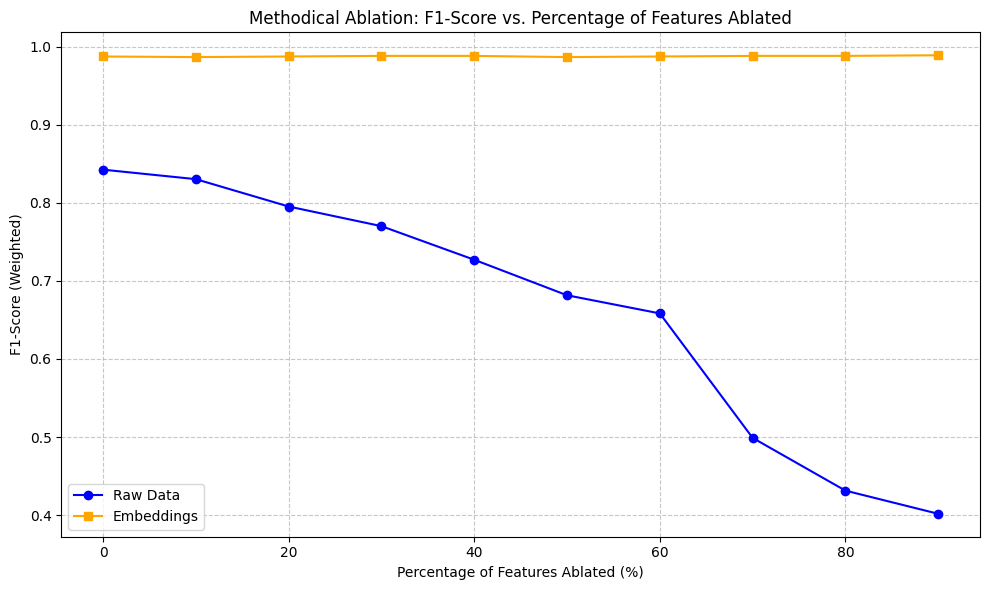


Methodical Ablation completed.


In [ ]:
# --- Methodical Ablation ---
print("\nPerforming Methodical Ablation...")

# Define ablation percentages
ablation_percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Initialize lists to store F1-scores
f1_scores_raw = []
f1_scores_emb = []

# --- Ablation for Raw Data ---
print("Ablating features for Raw Data...")
# Get sorted feature indices based on combined importance
feature_ranking_raw = combined_importance_raw['Feature'].tolist()
num_features_raw = len(feature_ranking_raw)

# Copy original training and test data
X_train_raw_ablate = X_train_raw.copy()
X_test_raw_ablate = X_test_raw.copy()

# Baseline model (no ablation)
rf_clf_raw_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf_raw_baseline.fit(X_train_raw_ablate, y_train_raw)
y_pred_raw_baseline = rf_clf_raw_baseline.predict(X_test_raw_ablate)
f1_raw_baseline = f1_score(y_test_raw, y_pred_raw_baseline, average='weighted')
f1_scores_raw.append(f1_raw_baseline)
print(f"Baseline F1-Score (Raw Data, 0% ablated): {f1_raw_baseline:.4f}")

# Perform ablation for each percentage
for perc in ablation_percentages:
    num_features_to_ablate = int(num_features_raw * perc)
    features_to_ablate = feature_ranking_raw[:num_features_to_ablate]

    # Set selected features to zero in training and test data
    feature_indices = [X_columns.index(feat) for feat in features_to_ablate]
    X_train_raw_ablate[:, feature_indices] = 0
    X_test_raw_ablate[:, feature_indices] = 0

    # Retrain model
    rf_clf_raw = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_clf_raw.fit(X_train_raw_ablate, y_train_raw)

    # Evaluate F1-score
    y_pred_raw = rf_clf_raw.predict(X_test_raw_ablate)
    f1_raw = f1_score(y_test_raw, y_pred_raw, average='weighted')
    f1_scores_raw.append(f1_raw)
    print(f"F1-Score (Raw Data, {int(perc*100)}% ablated): {f1_raw:.4f}")

# --- Ablation for Embeddings ---
print("\nAblating features for Embeddings...")
# Get sorted feature indices based on combined importance
embedding_feature_names = [f'Embedding_{i}' for i in range(X_test_emb.shape[1])]
feature_ranking_emb = combined_importance_emb['Feature'].tolist()
num_features_emb = len(feature_ranking_emb)

# Copy original training and test data
X_train_emb_ablate = X_train_emb.copy()
X_test_emb_ablate = X_test_emb.copy()

# Baseline model (no ablation)
rf_clf_emb_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf_emb_baseline.fit(X_train_emb_ablate, y_train_emb)
y_pred_emb_baseline = rf_clf_emb_baseline.predict(X_test_emb_ablate)
f1_emb_baseline = f1_score(y_test_emb, y_pred_emb_baseline, average='weighted')
f1_scores_emb.append(f1_emb_baseline)
print(f"Baseline F1-Score (Embeddings, 0% ablated): {f1_emb_baseline:.4f}")

# Perform ablation for each percentage
for perc in ablation_percentages:
    num_features_to_ablate = int(num_features_emb * perc)
    features_to_ablate = feature_ranking_emb[:num_features_to_ablate]

    # Set selected features to zero in training and test data
    feature_indices = [embedding_feature_names.index(feat) for feat in features_to_ablate]
    X_train_emb_ablate[:, feature_indices] = 0
    X_test_emb_ablate[:, feature_indices] = 0

    # Retrain model
    rf_clf_emb = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_clf_emb.fit(X_train_emb_ablate, y_train_emb)

    # Evaluate F1-score
    y_pred_emb = rf_clf_emb.predict(X_test_emb_ablate)
    f1_emb = f1_score(y_test_emb, y_pred_emb, average='weighted')
    f1_scores_emb.append(f1_emb)
    print(f"F1-Score (Embeddings, {int(perc*100)}% ablated): {f1_emb:.4f}")

# --- Visualize Methodical Ablation Curve ---
# Plot F1-scores vs. ablation percentages
plt.figure(figsize=(10, 6))
percentages = [0] + ablation_percentages  # Include 0% for baseline
plt.plot([p * 100 for p in percentages], f1_scores_raw, marker='o', label='Raw Data', color='blue')
plt.plot([p * 100 for p in percentages], f1_scores_emb, marker='s', label='Embeddings', color='orange')
plt.title("Methodical Ablation: F1-Score vs. Percentage of Features Ablated")
plt.xlabel("Percentage of Features Ablated (%)")
plt.ylabel("F1-Score (Weighted)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print("\nMethodical Ablation completed.")


Performing Random Ablation...
Randomly ablating features for Raw Data...
Baseline F1-Score (Raw Data, 0% ablated): 0.8425
Average F1-Score (Raw Data, 10% ablated, 25 iterations): 0.8417
Average F1-Score (Raw Data, 20% ablated, 25 iterations): 0.8322
Average F1-Score (Raw Data, 30% ablated, 25 iterations): 0.8277
Average F1-Score (Raw Data, 40% ablated, 25 iterations): 0.8090
Average F1-Score (Raw Data, 50% ablated, 25 iterations): 0.8038
Average F1-Score (Raw Data, 60% ablated, 25 iterations): 0.7876
Average F1-Score (Raw Data, 70% ablated, 25 iterations): 0.7443
Average F1-Score (Raw Data, 80% ablated, 25 iterations): 0.6936
Average F1-Score (Raw Data, 90% ablated, 25 iterations): 0.5367

Randomly ablating features for Embeddings...
Baseline F1-Score (Embeddings, 0% ablated): 0.9874
Average F1-Score (Embeddings, 10% ablated, 25 iterations): 0.9882
Average F1-Score (Embeddings, 20% ablated, 25 iterations): 0.9882
Average F1-Score (Embeddings, 30% ablated, 25 iterations): 0.9879
Averag

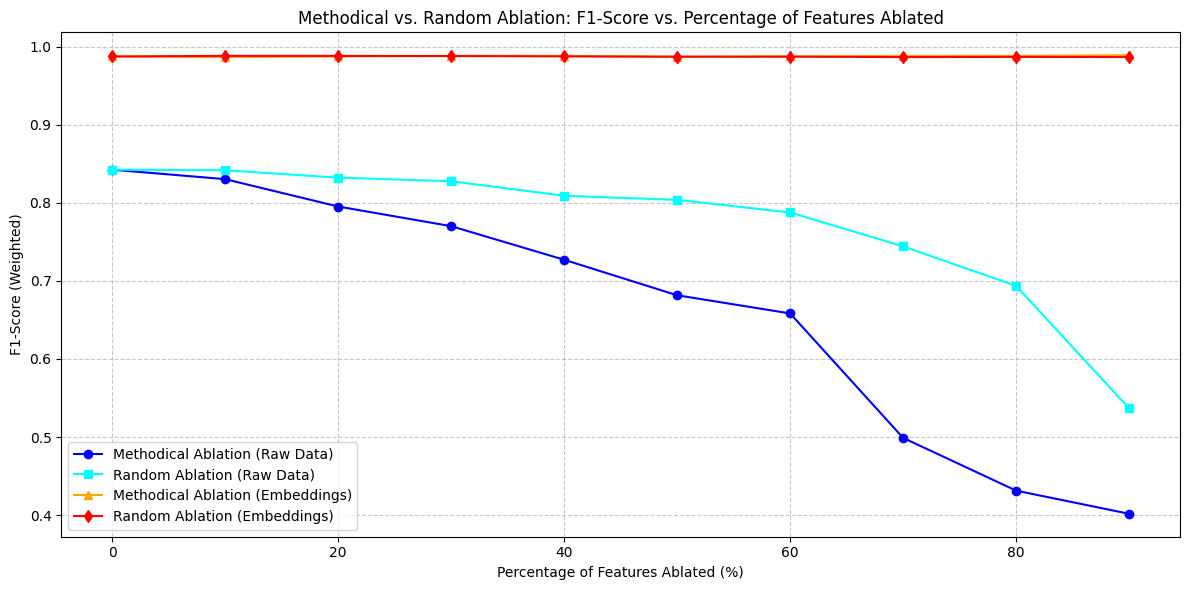

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# --- Random Ablation ---
print("\nPerforming Random Ablation...")

# Define ablation percentages and number of iterations
ablation_percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
num_iterations = 25

# Initialize lists to store average F1-scores
f1_scores_random_raw = []
f1_scores_random_emb = []

# --- Random Ablation for Raw Data ---
print("Randomly ablating features for Raw Data...")
num_features_raw = X_train_raw.shape[1]

# Baseline F1-score (already computed in methodical ablation)
f1_scores_random_raw.append(f1_scores_raw[0])  # Use methodical ablation baseline
print(f"Baseline F1-Score (Raw Data, 0% ablated): {f1_scores_raw[0]:.4f}")

# Perform random ablation for each percentage
for perc in ablation_percentages:
    f1_scores_iter = []
    num_features_to_ablate = int(num_features_raw * perc)

    for _ in range(num_iterations):
        # Randomly select features to ablate
        feature_indices = np.random.choice(num_features_raw, size=num_features_to_ablate, replace=False)

        # Copy original data
        X_train_raw_ablate = X_train_raw.copy()
        X_test_raw_ablate = X_test_raw.copy()

        # Set selected features to zero
        X_train_raw_ablate[:, feature_indices] = 0
        X_test_raw_ablate[:, feature_indices] = 0

        # Retrain model
        rf_clf_raw = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_clf_raw.fit(X_train_raw_ablate, y_train_raw)

        # Evaluate F1-score
        y_pred_raw = rf_clf_raw.predict(X_test_raw_ablate)
        f1_raw = f1_score(y_test_raw, y_pred_raw, average='weighted')
        f1_scores_iter.append(f1_raw)

    # Compute average F1-score across iterations
    avg_f1_raw = np.mean(f1_scores_iter)
    f1_scores_random_raw.append(avg_f1_raw)
    print(f"Average F1-Score (Raw Data, {int(perc*100)}% ablated, {num_iterations} iterations): {avg_f1_raw:.4f}")

# --- Random Ablation for Embeddings ---
print("\nRandomly ablating features for Embeddings...")
num_features_emb = X_train_emb.shape[1]

# Baseline F1-score (already computed in methodical ablation)
f1_scores_random_emb.append(f1_scores_emb[0])  # Use methodical ablation baseline
print(f"Baseline F1-Score (Embeddings, 0% ablated): {f1_scores_emb[0]:.4f}")

# Perform random ablation for each percentage
for perc in ablation_percentages:
    f1_scores_iter = []
    num_features_to_ablate = int(num_features_emb * perc)

    for _ in range(num_iterations):
        # Randomly select features to ablate
        feature_indices = np.random.choice(num_features_emb, size=num_features_to_ablate, replace=False)

        # Copy original data
        X_train_emb_ablate = X_train_emb.copy()
        X_test_emb_ablate = X_test_emb.copy()

        # Set selected features to zero
        X_train_emb_ablate[:, feature_indices] = 0
        X_test_emb_ablate[:, feature_indices] = 0

        # Retrain model
        rf_clf_emb = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_clf_emb.fit(X_train_emb_ablate, y_train_emb)

        # Evaluate F1-score
        y_pred_emb = rf_clf_emb.predict(X_test_emb_ablate)
        f1_emb = f1_score(y_test_emb, y_pred_emb, average='weighted')
        f1_scores_iter.append(f1_emb)

    # Compute average F1-score across iterations
    avg_f1_emb = np.mean(f1_scores_iter)
    f1_scores_random_emb.append(avg_f1_emb)
    print(f"Average F1-Score (Embeddings, {int(perc*100)}% ablated, {num_iterations} iterations): {avg_f1_emb:.4f}")

# --- Visualize Methodical vs. Random Ablation ---
# Plot F1-scores vs. ablation percentages
percentages = [0] + ablation_percentages  # Include 0% for baseline
plt.figure(figsize=(12, 6))

# Raw Data
plt.plot([p * 100 for p in percentages], f1_scores_raw, marker='o', label='Methodical Ablation (Raw Data)', color='blue')
plt.plot([p * 100 for p in percentages], f1_scores_random_raw, marker='s', label='Random Ablation (Raw Data)', color='cyan')

# Embeddings
plt.plot([p * 100 for p in percentages], f1_scores_emb, marker='^', label='Methodical Ablation (Embeddings)', color='orange')
plt.plot([p * 100 for p in percentages], f1_scores_random_emb, marker='d', label='Random Ablation (Embeddings)', color='red')

plt.title("Methodical vs. Random Ablation: F1-Score vs. Percentage of Features Ablated")
plt.xlabel("Percentage of Features Ablated (%)")
plt.ylabel("F1-Score (Weighted)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()


Calculating AUC for Methodical and Random Ablation...
AUC for Methodical Ablation (Raw Data): 0.6015
AUC for Random Ablation (Raw Data): 0.7029
AUC for Methodical Ablation (Embeddings): 0.8889
AUC for Random Ablation (Embeddings): 0.8887


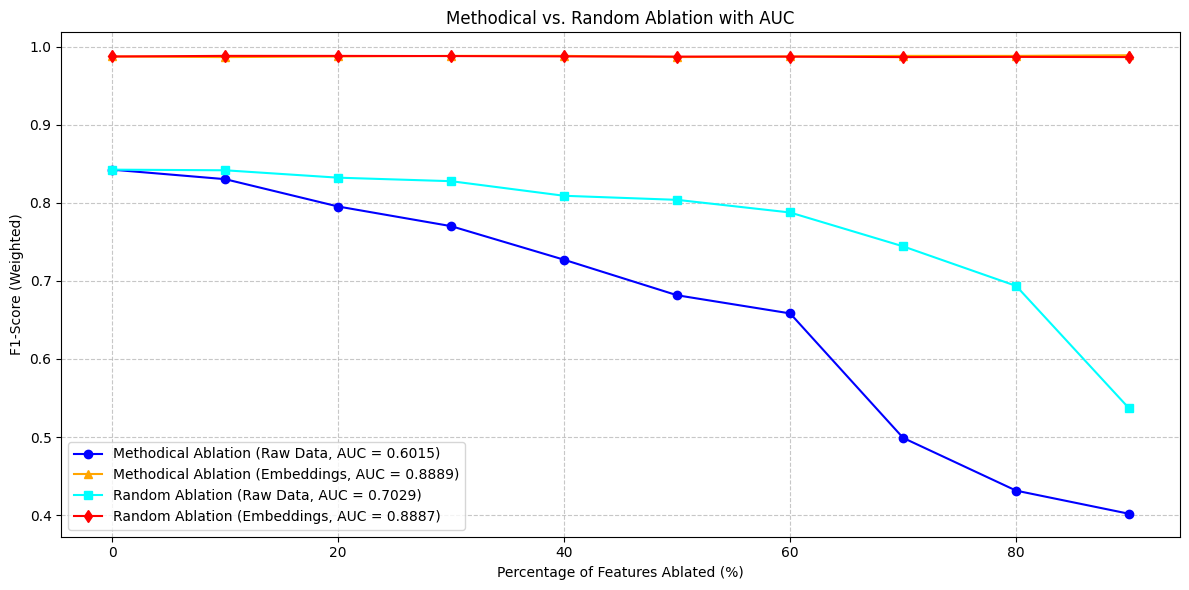


AUC calculation and visualization for Methodical and Random Ablation completed.


In [ ]:
from sklearn.metrics import auc

# --- Calculate AUC for Methodical and Random Ablation ---
print("\nCalculating AUC for Methodical and Random Ablation...")

# Define percentages for x-axis (including 0% baseline)
percentages = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
percentages_scaled = [p * 100 for p in percentages]  # Convert to percentage for plotting

# Compute AUC using trapezoidal rule
auc_methodical_raw = auc(percentages, f1_scores_raw)
auc_random_raw = auc(percentages, f1_scores_random_raw)
auc_methodical_emb = auc(percentages, f1_scores_emb)
auc_random_emb = auc(percentages, f1_scores_random_emb)

# Print AUC values
print(f"AUC for Methodical Ablation (Raw Data): {auc_methodical_raw:.4f}")
print(f"AUC for Random Ablation (Raw Data): {auc_random_raw:.4f}")
print(f"AUC for Methodical Ablation (Embeddings): {auc_methodical_emb:.4f}")
print(f"AUC for Random Ablation (Embeddings): {auc_random_emb:.4f}")

# --- Visualize Ablation Curves with AUC ---
plt.figure(figsize=(12, 6))

# Plot Methodical Ablation
plt.plot(percentages_scaled, f1_scores_raw, marker='o', label=f'Methodical Ablation (Raw Data, AUC = {auc_methodical_raw:.4f})', color='blue')
plt.plot(percentages_scaled, f1_scores_emb, marker='^', label=f'Methodical Ablation (Embeddings, AUC = {auc_methodical_emb:.4f})', color='orange')

# Plot Random Ablation
plt.plot(percentages_scaled, f1_scores_random_raw, marker='s', label=f'Random Ablation (Raw Data, AUC = {auc_random_raw:.4f})', color='cyan')
plt.plot(percentages_scaled, f1_scores_random_emb, marker='d', label=f'Random Ablation (Embeddings, AUC = {auc_random_emb:.4f})', color='red')

plt.title("Methodical vs. Random Ablation with AUC")
plt.xlabel("Percentage of Features Ablated (%)")
plt.ylabel("F1-Score (Weighted)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print("\nAUC calculation and visualization for Methodical and Random Ablation completed.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc

# --- Calculate diffAUC ---
print("\nCalculating diffAUC for Ablation Curves...")

# Compute diffAUC (Methodical AUC - Random AUC, but typically Random - Methodical for sensitivity)
diff_auc_raw = auc_random_raw - auc_methodical_raw
diff_auc_emb = auc_random_emb - auc_methodical_emb

# Print diffAUC values
print(f"diffAUC (Raw Data): {diff_auc_raw:.4f}")
print(f"diffAUC (Embeddings): {diff_auc_emb:.4f}")

# Interpretation
if diff_auc_raw > 0:
    print("Interpretation (Raw Data): The model is more sensitive to the removal of XAI-ranked features (methodical ablation causes a greater F1-score drop than random ablation), validating the importance ranking.")
else:
    print("Interpretation (Raw Data): The model shows similar sensitivity to both methodical and random ablation, suggesting the XAI ranking may not strongly differentiate important features.")

if diff_auc_emb > 0:
    print("Interpretation (Embeddings): The model is more sensitive to the removal of XAI-ranked features (methodical ablation causes a greater F1-score drop than random ablation), validating the importance ranking.")
else:
    print("Interpretation (Embeddings): The model shows similar sensitivity to both methodical and random ablation, suggesting the XAI ranking may not strongly differentiate important features.")

print("\ndiffAUC calculation and visualization completed.")


Calculating diffAUC for Ablation Curves...
diffAUC (Raw Data): 0.1014
diffAUC (Embeddings): -0.0002
Interpretation (Raw Data): The model is more sensitive to the removal of XAI-ranked features (methodical ablation causes a greater F1-score drop than random ablation), validating the importance ranking.
Interpretation (Embeddings): The model shows similar sensitivity to both methodical and random ablation, suggesting the XAI ranking may not strongly differentiate important features.

diffAUC calculation and visualization completed.
